# テーマ2 データ可視化とEDA

## 目的
- EDA を「モデル作成前の観察と仮説づくり」として理解する
- 分布、グループ差、変数の関係をグラフで確認し、読み方を覚える
- グラフを見て、特徴量の違いやクラスごとの傾向を言葉で説明する

## 今日の成果物
- ヒストグラム、箱ひげ図、散布図を含むグラフを3つ以上作る
- それぞれのグラフから読み取れることを短く記述する

## 注意
- このNotebookは上から順に実行してください
- `TODO` は小さな変更で進められるようにしてあります

## EDAとは何か

EDA は Exploratory Data Analysis の略で、日本語では探索的データ分析と呼ばれます。
目的は、モデルを作る前にデータを観察して仮説を立てることです。

この回では、数値計算よりも**グラフを読むこと**を重視します。

| 観点 | 見るもの | 使うグラフ |
| --- | --- | --- |
| 構成比 | クラスやカテゴリの割合 | 円グラフ、棒グラフ |
| 分布 | 値がどの範囲に多いか | ヒストグラム |
| グループ差（平均） | クラスごとの平均 | 折れ線グラフ |
| グループ差（詳細） | クラスごとの中央値・ばらつき | 箱ひげ図 |
| 関係 | 2つの変数のつながり | 散布図 |

EDA では 「グラフ を作った」 で終わらず、**「その グラフ から何が言えそうか」** を
書くまで行います。

### グラフを読むときの型

グラフを見たら、次の3つを分けて書くと考えやすくなります。

1. **事実**: 図にそのまま見えていること
2. **解釈**: その事実から考えられること
3. **限界**: その図だけではまだ言えないこと

**例:** Irisデータにおいて`petal length (cm)` は品種ごとに分布が分かれて見える。
これは分類に役立つ特徴量かもしれない。ただし、図だけでは新しいデータを
必ず正しく分類できるとは言えない。

### 分析の流れ

このノートブックでは、Iris データを使って可視化の練習をします。

| Step | やること | 確認する観点 |
| --- | --- | --- |
| 0 | ライブラリとデータを準備 | 環境設定 |
| 1 | データを確認 | 行数、列名、概要 |
| 2 | シンプルなヒストグラム | 値の広がり、山の形 |
| 3 | ヒストグラム（品種ごと） | グループごとに分布を見る |
| 4 | 折れ線グラフで平均を確認 | 複数特徴量を一度に比べる |
| 5 | 円グラフでクラスの構成比 | 各クラスがバランスよくあるか |
| 6 | 箱ひげ図でグループ詳細 | 中央値、ばらつき、外れ値 |
| 7 | 散布図で2つの特徴量の関係 | 特徴量どうしの関連性 |

後半に「追加グラフ」と「ワインデータセットを使った演習」があります。
それらは発展なので、まず基本を完成させてから進みましょう。

---

### Step 0: グラフ描画の準備

Pythonでグラフを描くためのライブラリであるmatplotlib と seaborn を読み込みます。以降、グラフ関数を使い
`plt.show()` で表示します。

In [5]:
# ===== ライブラリ読み込み =====
import pandas as pd             # データフレーム操作用: 表形式のデータを扱うための定番ライブラリ
import matplotlib.pyplot as plt # グラフ描画用: 棒グラフや折れ線グラフなど、さまざまな図を描くための基本ライブラリ
import seaborn as sns           # データ可視化用: matplotlib をより美しく、より簡単に使えるようにした高機能ライブラリ
from sklearn.datasets import load_iris, load_wine # データセット読み込み用: 機械学習の練習用データを簡単に読み込めるライブラリ

# グラフの見た目をきれいにする設定
# 'whitegrid' は背景にうっすらと罫線を引くスタイル。データの高低が見やすくなります。
sns.set_theme(style='whitegrid')

# 日本語をグラフに表示するためのフォント設定（日本語がないと文字化けして ■ になってしまいます）
plt.rcParams['font.family'] = 'sans-serif' #フォントの設定
plt.rcParams['font.sans-serif'] = [
    'Hiragino Sans', 'Yu Gothic', 'Arial Unicode MS', 'DejaVu Sans'
] #フォントの設定: macOS / Windows / Linux でそれぞれ日本語を表示できるフォントを順に試します

---

### Step 1: データを読み込む

Iris データを DataFrame にします。
（テーマ1 で同じ操作をしています。ここでは、確認として読み込みます。）

In [6]:
# ===== Step 1: データ読み込み =====
# アヤメ（iris）のデータを読み込みます。
# as_frame=True を指定すると、pandas の DataFrame（表形式データ）として受け取れます。
iris = load_iris(as_frame=True)

# .copy() を使って「データのコピー」を作ります。
# コピーを作ることで、元のデータを誤って書き換えてしまう事故を防げます。
df = iris.frame.copy()

# 数値でしか入っていない 'target' 列を、品種名（setosa / versicolor / virginica）に変換します。
# dict(enumerate(iris.target_names)) は {0: 'setosa', 1: 'versicolor', 2: 'virginica'} のような対応表を作ります。
# .map() は、その対応表を使って数値を名前に置き換える機能です。
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

# 数値データが入っている列の名前だけを変数に保存しておきます。
# 後ほど「数値列どうしの相関を見る」際に再利用します。
numeric_columns = iris.feature_names

# df.shape は (行数, 列数) を返します。データの規模をひと目で確認できます。
print('行数, 列数 =', df.shape)

# 数値列の名前一覧を表示します。これが「特徴量（モデルが学習するデータ）」になります。
print('数値列 =', numeric_columns)

# df.head() は先頭 5 行を表として表示します。データの中身をざっと確認する定番の方法です。
display(df.head())

行数, 列数 = (150, 6)
数値列 = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


---

### Step 2: シンプルなヒストグラム

**ヒストグラムとは何か？**
ヒストグラムは、データの「分布（どの値がどれくらい多いか）」を棒グラムで表したものです。
値の範囲をいくつかの区間（**階級**）に分け、各区間に入るデータの個数（**度数**）を棒の高さで表します。

| 用語 | 意味 | 例（petal length） |
| --- | --- | --- |
| 階級（class） | 値を分ける区間 | 1.0〜1.5 cm、1.5〜2.0 cm、… |
| 度数（frequency） | その階級に入るデータ数 | 1.0〜1.5 cm に 37 個、など |
| 階級幅 | 1つの階級の幅 | 0.5 cm |

**階級のカッコの読み方:**
度数分布表やヒストグラムでは、階級を `[a, b)` のように書きます。
このカッコには「端を含めるか・含めないか」の意味があります。

- `[` （角かっこ）: 左端 **を含む**（その値以上）
- `)` （丸かっこ）: 右端 **を含まない**（その値未満）

つまり `[1.0, 1.328)` は **1.0 ≦ x < 1.328** を表します。
ちょうど 1.328 のデータは、この階級ではなく次の `[1.328, 1.656)` に入ります。
このように隣り合う階級の境界が重ならないようにすることで、
すべてのデータが確実にどれか1つの階級に分類されます。

ヒストグラムを見ると、次のことが分かります。
- どの範囲にデータが多いか（**ピーク / 山**）
- 山が1つか複数か（単峰 vs 多峰）
- 極端な値がありそうか（外れ値の有無）

**初心者のためにシンプルに** KDE 曲線は使わず、
棒グラフのみで表示します。これで分布の全体像がわかります。

> **補足:** ヒストグラムの見た目は階級幅（`bins`）で変わります。
> 階級幅を細かくしすぎるとノイズが目立ち、粗くしすぎると分布の形が潰れます。
> いろいろな `bins` の値を試して、最も読みやすい図を探してみましょう。

In [7]:
# ===== 度数分布表を作る =====
# ヒストグラムを描く前に、数値で「どの区間に何個入るか」を表にしてみます。
# これを「度数分布表（frequency table）」と呼びます。
# TODO: feature と bins を変えて、表の内容がどう変わるか観察する
feature = 'petal length (cm)'  # どの列の分布を見るかを指定します
n_bins = 18                    # 階級の数（ヒストグラムの棒の数と同じにします）

# pandas の cut() で値を n_bins 個の区間に分け、各区間に入るデータ数を数えます。
# right=False は「左端を含み、右端を含まない」区間にする設定（[a, b)）。
bins = pd.cut(df[feature], bins=n_bins, right=False)

# .value_counts().sort_index() で、各区間の度数を階級順に並べます。
freq_table = bins.value_counts().sort_index()

# 表示用に、階級の範囲と度数を DataFrame にして見やすくします。
freq_df = pd.DataFrame({
    '階級': freq_table.index.astype(str),
    '度数': freq_table.values,
})
freq_df.index = range(1, len(freq_df) + 1)  # 行番号を 1 から振り直す
freq_df.index.name = 'No.'

print(f'【度数分布表】 {feature}（階級数 = {n_bins}）')
display(freq_df)

【度数分布表】 petal length (cm)（階級数 = 18）


,階級,度数
No.,,
1,"[1.0, 1.328)",11
2,"[1.328, 1.656)",33
3,"[1.656, 1.983)",6
4,"[1.983, 2.311)",0
5,"[2.311, 2.639)",0
6,"[2.639, 2.967)",0
7,"[2.967, 3.294)",1
8,"[3.294, 3.622)",5
9,"[3.622, 3.95)",5


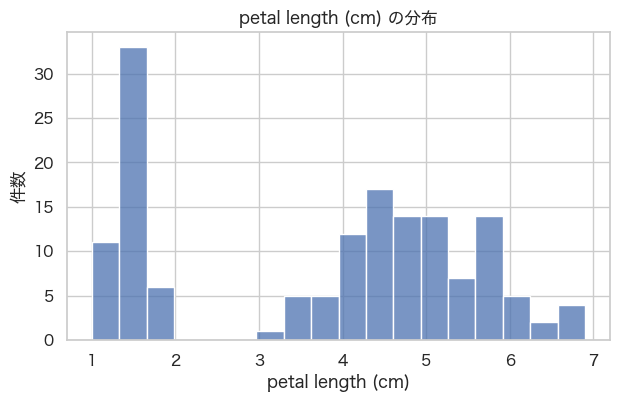

In [8]:
# ===== Step 2: シンプルなヒストグラム =====
# ヒストグラムは、データの「分布（どの値がどれくらい多いか）」を棒グラフで表したものです。
# TODO: feature を別の列に変えて、分布の違いを確認する
feature = 'petal length (cm)'  # どの列の分布を見るかを指定します

# グラフのサイズを幅7インチ、高さ4インチに設定します
plt.figure(figsize=(7, 4))

# sns.histplot がヒストグラムを描く関数です。
# data=df で使う表を指定し、x=feature で横軸にどの列を使うかを指定します。
# bins=18 は、データを18個の区間（階級）に分けるという意味です。この数を変えると棒の細かさが変わります。
sns.histplot(data=df, x=feature, bins=18)

# グラフのタイトルを設定します（f文字列で feature の中身を埋め込んでいます）
plt.title(f'{feature} の分布')

# 横軸と縦軸のラベル（名前）を設定します
plt.xlabel(feature)
plt.ylabel('件数')

# グラフを画面に表示します。これがないとグラフが描かれません。
plt.show()

**この図を見ると:**
- 横軸が値、縦軸が件数です。
- ピーク（山）はどの位置にありますか？
- 値の範囲はどこですか？

---

### Step 3: 品種ごとのヒストグラム

Step 2 のヒストグラムは全体の分布でしたが、次は**各クラスごとに色分け**して見ます。

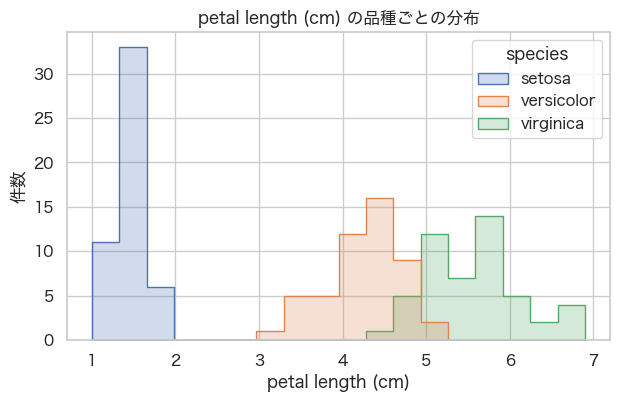

In [9]:
# ===== Step 3: 品種ごとのヒストグラム =====
# 品種（species）ごとに色を分けてヒストグラムを描くことで、
# 「どの品種がどの値の範囲に多いか」がひと目で分かるようになります。
# TODO: feature を変えて、品種ごとの差が見えやすい列を探す
feature = 'petal length (cm)'  # 見たい列を指定します

plt.figure(figsize=(7, 4))

# hue='species' が重要なポイントです。
# hue は「色分けの基準となる列」を指定する引数で、品種ごとに別の色で重ねて描画してくれます。
# element='step' は、棒を階段状の線で描く設定。重なった部分が見やすくなります。
sns.histplot(
    data=df,
    x=feature,
    hue='species',
    bins=18,
    element='step'
)

plt.title(f'{feature} の品種ごとの分布')
plt.xlabel(feature)
plt.ylabel('件数')
plt.show()

**観察のポイント:**
- setosa の`petal length` は短い方に、virginica は長い方に分布している。
- versicolor と virginica は一部重なっているが、全体として分かれている。しかし、単純にヒストグラムにした場合、一つの山に見える。

---

### Step 4: 折れ線グラフで品種ごとの平均を確認

**折れ線グラフは平均の違いをまとめて見る可視化** です。
箱ひげ図は1つの特徴量に注目しましたが、折れ線グラフなら
**複数の特徴量を一度**比べられます。

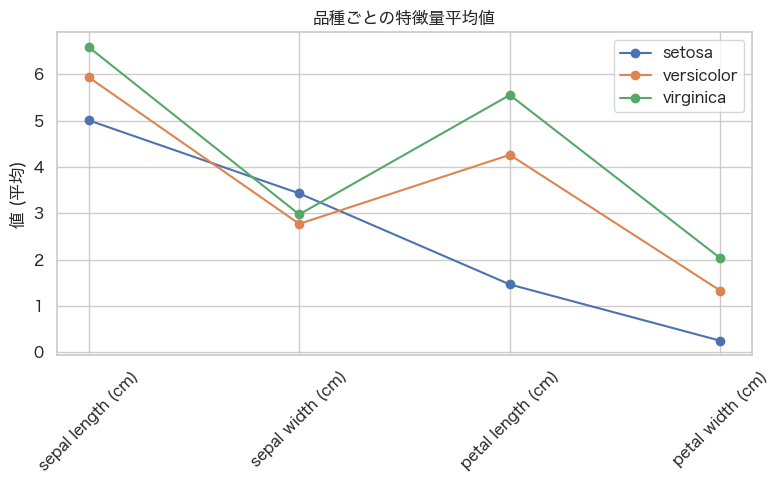

In [10]:
# ===== Step 4: 折れ線グラフ =====
# 各品種の「特徴量の平均値」を折れ線グラフで比べます。
# 折れ線グラフを使うと、複数の特徴量を1つの図で比較しやすくなります。
# TODO: どの品種でどの特徴量に差が大きいかを確認する

# groupby('species') で品種ごとにグループ分けし、
# [iris.feature_names] で数値列だけを取り出し、
# .mean() でその平均を計算しています。
# 結果として「品種 × 特徴量」の表ができます。
mean_by_species = df.groupby('species')[iris.feature_names].mean()

plt.figure(figsize=(8, 5))

# 品種ごとに1本ずつ線を引きます。
# mean_by_species.index には品種名（setosa, versicolor, virginica）が入っています。
for species in mean_by_species.index:
    # 横軸に特徴量の名前、縦軸にその品種の平均値を指定して線を引きます。
    # marker='o' はデータ点に丸印をつける設定。label=species は凡例（グラフの色の説明）に品種名を表示します。
    plt.plot(
        mean_by_species.columns,
        mean_by_species.loc[species],
        marker='o',
        label=species
    )

plt.title('品種ごとの特徴量平均値')
plt.xticks(rotation=45)  # 横軸の文字を45度傾けて読みやすくします
plt.legend()             # 凡例（色と品種名の対応）を表示します
plt.ylabel('値 (平均)')
plt.tight_layout()       # グラフの要素が重ならないよう、余白を自動調整します
plt.show()

**観察のポイント:**
- petal の2つで品種ごとの開き（差）が sepal より大きい。
- 折れ線の順序と品種の対応関係、重なり方も確認できる。

---

### Step 5: 円グラフでクラスの構成比を見る

分析の入り口として、各クラスが何サンプルずつあるかを確認します。
クラス間に大きな偏りがある場合、モデルの評価に影響することがあるので
最初にチェックしておくと安心です。

#### 解説: 円グラフとは

円グラフは、カテゴリごとの割合を視覚的に把握するのに適しています。
全体に対する各クラスの大きさがひと目でわかります。

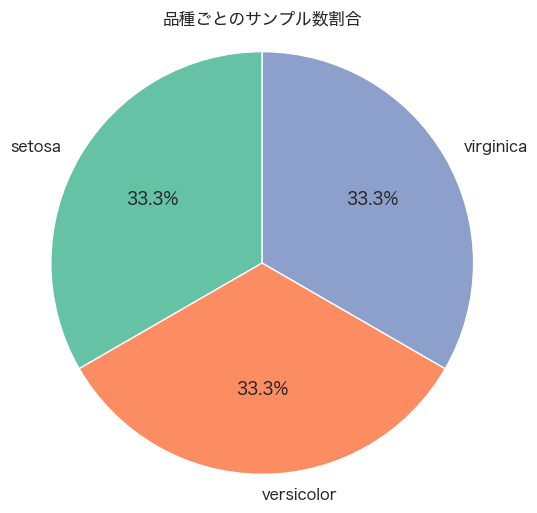

In [11]:
# ===== Step 5: 円グラフ =====
# TODO: 各品種の割合がどうなっているか確認する
species_count = df['species'].value_counts()

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    species_count.values,
    labels=species_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66c2a5', '#fc8d62', '#8da0cb']
)
plt.title('品種ごとのサンプル数割合')
plt.axis('equal')
plt.show()

**観察のポイント:**
- 3品種がそれぞれ約33.3%ずつの割合になっている。
- クラス間の偏りがないため、各品種を同程度に扱って観察しやすい。

---

### Step 6: 箱ひげ図でグループごとの差を見る

ヒストグラムは分布の全体像を見るのに向いています。
箱ひげ図では、品種ごとの中央値やばらつきの**違い**を比較しやすくします。

# ===== Step 7: 散布図 =====
# 散布図は、2つの特徴量の「関係性」を点の集まりで表したものです。
# 2つの列を横軸・縦軸に割り当て、各サンプルを1つの点としてプロットします。
# 点が右上に集まっていれば「両方が大きい」傾向、左下に集まれば「両方が小さい」傾向があることが分かります。
# TODO: x_feature と y_feature を変えて、品種が分かれやすい組み合わせを探す
x_feature = 'petal length (cm)'  # 横軸に使う列
y_feature = 'petal width (cm)'   # 縦軸に使う列

plt.figure(figsize=(7, 5))

# sns.scatterplot が散布図を描く関数です。
# x=, y= で横軸・縦軸の列を指定します。
# hue='species' で品種ごとに色を変えます。これで「どの品種がどのあたりに集まっているか」が分かります。
# s=70 は点のサイズを指定しています（デフォルトより少し大きめにして見やすくしています）。
sns.scatterplot(data=df, x=x_feature, y=y_feature, hue='species', s=70)

plt.title(f'{x_feature} と {y_feature} の散布図')
plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.show()

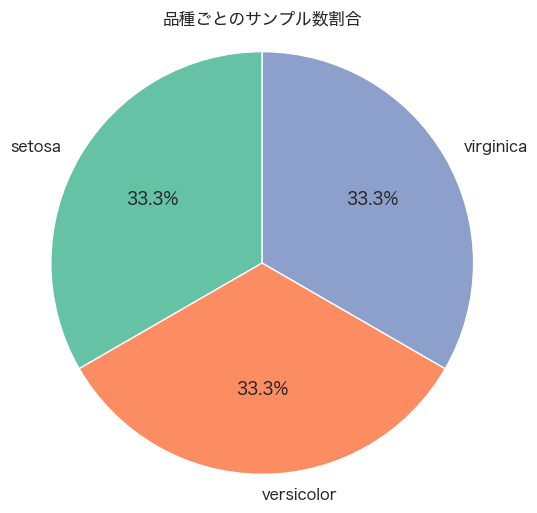

In [12]:
# ===== Step 5: 円グラフ =====
# 円グラフは、全体に対する「割合（パーセンテージ）」を見るのに適しています。
# ここでは各品種のサンプル数が全体の何%を占めているかを確認します。
# TODO: 各品種の割合がどうなっているか確認する

# value_counts() は、列の中にある値がそれぞれいくつあるかを数えてくれる便利な関数です。
# 結果は「値の多い順」に並びます。
species_count = df['species'].value_counts()

plt.figure(figsize=(6, 6))

# plt.pie が円グラフを描く関数です。
# species_count.values には各品種の個数が入っています。
# labels=species_count.index で各ピースに品種名を表示します。
# autopct='%1.1f%%' は、各ピースに「何%か」を小数点1桁まで表示する設定です。
# startangle=90 は、円グラフの開始位置を「上（12時の方向）」にする設定です。
# colors= で3つの品種にそれぞれ別の色を割り当てています。
wedges, texts, autotexts = plt.pie(
    species_count.values,
    labels=species_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66c2a5', '#fc8d62', '#8da0cb']
)

plt.title('品種ごとのサンプル数割合')
# axis('equal') は、縦と横の比率を同じにする設定です。
# これがないと円が楕円に潰れてしまうので、円グラフでは必ず指定します。
plt.axis('equal')
plt.show()

**観察のポイント:**
- 3品種の箱がお互いに離れた位置にある → この特徴量で品種を区別しやすい
- 箱の高さが小さい → その品種の中ではばらつきが小さい
- 箱が重なっている → どの品種に属するか判断しにくい領域がある

---

### Step 7: 散布図で2つの特徴量の関係を見る

散布図では、2つの特徴量を見て、「一緒に動くか」「品種によって分かれるか」を確認できます。

# ===== 相関ヒートマップ =====
# 「相関」とは、2つの数値列の間に「一方が大きいともう一方も大きい（または小さい）」といった
# 関係があるかどうかを示す指標です。-1 〜 +1 の範囲で表されます。
# +1 に近い＝両方が一緒に増える、-1 に近い＝一方が増えるともう一方が減る、0 に近い＝関係が薄い、となります。

# .corr() は、数値列どうしの相関をすべて計算して「相関行列」という表を作る関数です。
# numeric_only=True は、数値列だけを対象にするという指定です（文字列の列は計算できないため除外します）。
corr_matrix = df[numeric_columns].corr(numeric_only=True)

plt.figure(figsize=(7, 5))

# sns.heatmap がヒートマップ（色の濃淡で数値の大きさを表す図）を描く関数です。
# annot=True は、各マスに数値を書き込む設定です。
# cmap='Blues' は、色のグラデーションを青系にする設定です。
# fmt='.2f' は、表示する数値を小数点以下2桁に丸める設定です。
# square=True は、各マスを正方形にする設定で、見た目が整います。
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', square=True)

plt.title('数値列どうしの相関ヒートマップ')
plt.show()

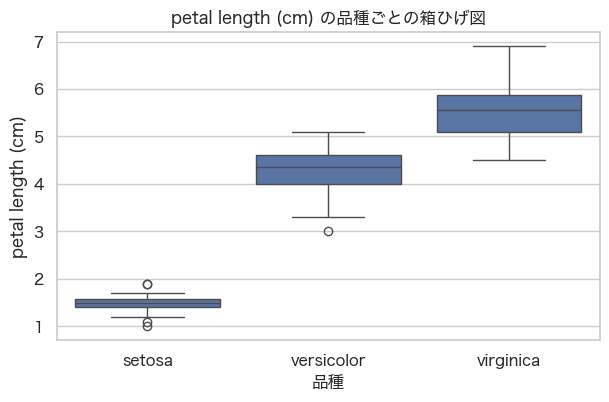

In [13]:
# ===== Step 6: 箱ひげ図 =====
# 箱ひげ図は、データの「ばらつき方」や「外れ値（極端に外れた値）」を視覚的に確認するのに適しています。
# 箱の中央の線が「中央値（データを順に並べたとき真ん中にくる値）」、
# 箱の上下端が「上位25%の境界 / 下位25%の境界」を表します。
# TODO: target_feature を別の列に変えて、分かれやすい特徴量を探す
target_feature = 'petal length (cm)'  # 縦軸に表示したい列を指定します

plt.figure(figsize=(7, 4))

# sns.boxplot が箱ひげ図を描く関数です。
# x='species' で横軸に品種を、y=target_feature で縦軸に見たい特徴量を指定します。
# 品種ごとに箱が分かれて表示されるので、値の分布の違いが比較しやすくなります。
sns.boxplot(data=df, x='species', y=target_feature)

plt.title(f'{target_feature} の品種ごとの箱ひげ図')
plt.xlabel('品種')
plt.ylabel(target_feature)
plt.show()

**観察のポイント:**
- setosa が左上に、virginica が右下に集まっている → petal の2つでよく区別できる
- versicolor は setosa と virginica の中間に位置している
- 右上がりの傾向がある → petal length と petal width は正の相関がある

# ===== pairplot =====
# pairplot は、すべての数値列の「2列の組み合わせ」について散布図を一気に描いてくれる超便利な機能です。
# 対角線上にはヒストグラムが描かれ、それ以外のマスには各ペアの散布図が描かれます。
# これを1枚描くだけで、どの列の組み合わせが品種を分けやすいかがひと目で分かります。

# 描画に使う列として、数値列（4つ）に品種名を追加します。
# hue='species' で色分けするために、品種名の列も含める必要があります。
pairplot_columns = iris.feature_names + ['species']

# sns.pairplot がこの図を描く関数です。
# hue='species' で品種ごとに色を変えます。
# corner=True は、左下の半分だけを描く設定です（右上は左下の鏡像なので省略してすっきりさせます）。
g = sns.pairplot(df[pairplot_columns], hue='species', corner=True)

plt.show()

### ヒートマップで相関を確認

散布図は2変数ずつ見る方法でした。ヒートマップを使えば**特徴量どうしの関係を一度に数値で**確認できます。

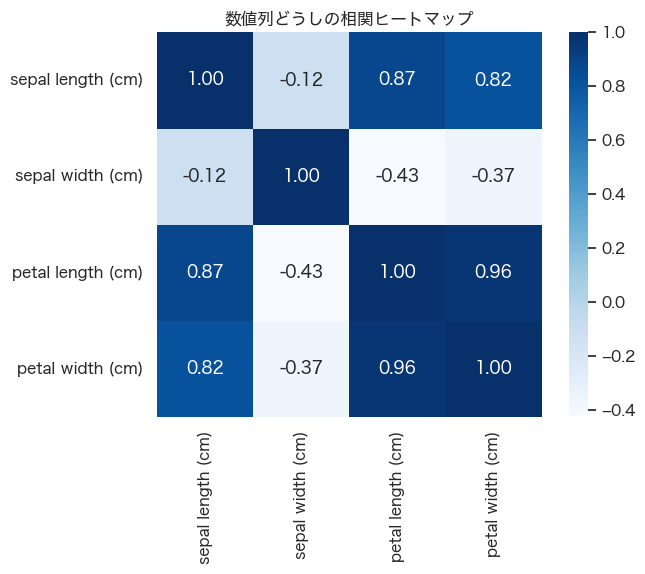

In [14]:
# ===== 相関ヒートマップ =====
corr_matrix = df[numeric_columns].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', square=True)
plt.title('数値列どうしの相関ヒートマップ')
plt.show()

### pairplot で全体像を確認

ここで紹介するpairplot は、すべての特徴量どうしの散布図を一緒に並べます。
対角線には各特徴量の分布が描かれます。

In [15]:
# ===== IQR で外れ値候補を確認 =====
# IQR（四分位範囲：Inter-Quartile Range）は、データの中央50%がどれくらいの幅に広がっているかを示す値です。
# これを使って「外れ値（極端に外れた値）」を数値的に判定するのが、機械学習の定番手法のひとつです。
# TODO: feature_to_check を変えて、外れ値候補の件数を確認する
feature_to_check = 'sepal width (cm)'  # 外れ値を確認したい列を指定します

# quantile(0.25) は「下から25%の位置の値（第1四分位数：Q1）」を取得します。
# つまり、データを小さい順に並べたとき、下から4分の1のところにある値です。
q1   = df[feature_to_check].quantile(0.25)

# quantile(0.75) は「下から75%の位置の値（第3四分位数：Q3）」を取得します。
q3   = df[feature_to_check].quantile(0.75)

# IQR は Q3 と Q1 の差です。データの中央50%の広がりを表します。
iqr  = q3 - q1

# 外れ値の基準となる下限と上限を計算します。
# 一般的なルールでは「Q1 - 1.5×IQR より小さい」または「Q3 + 1.5×IQR より大きい」値を外れ値とみなします。
low  = q1 - 1.5 * iqr  # 下限：これより小さい値は外れ値の候補
high = q3 + 1.5 * iqr  # 上限：これより大きい値は外れ値の候補

# 外れ値候補だけを取り出します。
# 条件を ( ) で囲み、|（縦棒）でつなぐことで「下限より小さい または 上限より大きい」という
# 2つの条件のどちらかを満たす行だけを抽出しています。
outliers = df[
    (df[feature_to_check] < low) | (df[feature_to_check] > high)
]

# 結果をわかりやすく表示します。
print('確認する列 =', feature_to_check)
print('下限 =', round(low, 2))   # round(..., 2) で小数点以下2桁に丸めて見やすくします
print('上限 =', round(high, 2))
print('外れ値候補の件数 =', len(outliers))  # len() で外れ値の行数を数えます

# 外れ値候補のデータの中身を表示します（先頭5行だけ）。
# 特徴量の値と品種名だけを表示して、どの品種に外れ値が多いかを確認できます。
display(outliers[[feature_to_check, 'species']].head())

確認する列 = sepal width (cm)
下限 = 2.05
上限 = 4.05
外れ値候補の件数 = 4


,sepal width (cm),species
15,4.4,setosa
32,4.1,setosa
33,4.2,setosa
60,2.0,versicolor


### IQR で外れ値の候補を探す

箱ひげ図で外れ値を目で確認できましたが、ここでは数値でも見てみます。

**IQR の考え方:**
- `IQR = Q3 - Q1` （第3四分位数 - 第1四分位数）
- 下限: `Q1 - 1.5 × IQR`
- 上限: `Q3 + 1.5 × IQR`
- この範囲外にある値を「外れ値候補」とします

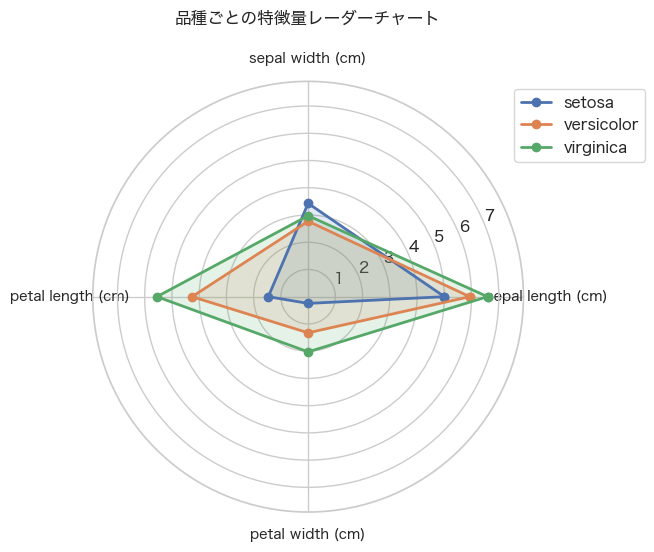

In [16]:
# ===== レーダーチャート =====
# レーダーチャートは、複数の特徴量を1つの図で比較するのに適したグラフです。
# 各特徴量が1方向の軸になり、値が大きいほど外側に広がります。
# 品種ごとに「形」が違うので、どの品種がどの特徴で優れているかがひと目で分かります。
# TODO: 生成された図形から、どの品種が最も幅広い輪郭を持つかを確認する
import numpy as np  # numpy は数値計算の定番ライブラリ。角度の計算などに使います。

# 品種ごとの各特徴量の平均値を計算します（Step 4 と同じ処理です）。
mean_by_species = df.groupby('species')[iris.feature_names].mean()

# 特徴量の名前のリストを取得します（これがレーダーチャートの各軸のラベルになります）。
features = iris.feature_names

# 軸の数（＝特徴量の数）を取得します。アヤメなら4つです。
num_vars = len(features)

# np.linspace(0, 2π, num_vars) は、0 から 2π（360度）の間を num_vars 個に等分した角度を作ります。
# endpoint=False は、最後の点（2π）を含めない設定です（最初の点0と同じ角度になるのを防ぐため）。
# .tolist() で numpy 配列を普通のリストに変換します。
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# レーダーチャートを「閉じた形」にするため、最初の角度をリストの最後にもう一度追加します。
# これがないと、最後の軸から最初の軸に線が引かれず、図が開いたままになってしまいます。
angles += angles[:1]  # 閉じるために最初の角度を最後に追加

plt.figure(figsize=(7, 7))

# subplot(111, projection='polar') は、極座標（円形の座標系）でグラフを描くための領域を作ります。
# 111 は「1行1列の1番目」という意味で、1つの図だけを描く場合の定番の指定です。
ax = plt.subplot(111, projection='polar')

# 品種ごとに1本ずつ線を引きます。
for species in mean_by_species.index:
    # その品種の平均値を行から取り出し、リストに変換します。
    values = mean_by_species.loc[species].values.flatten().tolist()

    # 図を閉じるため、最初の値をリストの最後にもう一度追加します（角度と同じ理由です）。
    values += values[:1]  # 閉じるために最初の値を最後に追加

    # ax.plot で線を、ax.fill で内側を薄く塗りつぶします。
    # linewidth=2 は線の太さ、marker='o' はデータ点に丸印、alpha=0.15 は塗りつぶしの透明度です。
    ax.plot(angles, values, linewidth=2, label=species, marker='o')
    ax.fill(angles, values, alpha=0.15)

# 各軸の位置に特徴量名を表示します（angles[:-1] は最後の重複した角度を除外したリストです）。
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=10)

# 縦軸（半径）の範囲を設定します。
# 最大値の1.2倍まで表示することで、線が図の外枠にぴったり寄りすぎないようにしています。
ax.set_ylim(0, max(mean_by_species.max()) * 1.2)

# pad=20 はタイトルと図の間に余白を入れる設定です。
ax.set_title('品種ごとの特徴量レーダーチャート', pad=20)

# 凡例を表示します。bbox_to_anchor で凡例の位置を少し外側にずらしています。
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

### レーダーチャートで品種を比較する

レーダーチャートは、各特徴量を**角度方向に配置し、品種ごとの平均値を輪郭**として描きます。
形が異なれば、品種ごとの特徴の傾向が見えやすくなります。

In [17]:
# ===== ワインデータの準備 =====
# アヤメとは別の「ワイン（wine）」データを読み込みます。
# ワインデータは特徴量が13個もあり、アヤメ（4個）より複雑なデータです。
# as_frame=True で pandas の DataFrame として受け取ります。
wine = load_wine(as_frame=True)

# 元データを誤って書き換えないよう、コピーを作成します。
wine_df = wine.frame.copy()

# アヤメでやったのと同じように、数値のクラスラベルを分かりやすい名前に変換します。
# wine.target_names にはクラス名（class_0, class_1, class_2）が入っています。
wine_df['class_name'] = wine_df['target'].map(
    dict(enumerate(wine.target_names))
)

# 特徴量（数値データ）の列名を変数に保存します。後ほどの分析で使います。
wine_numeric_columns = wine.feature_names

# データの規模（行数と列数）を確認します。
print('行数, 列数 =', wine_df.shape)

# クラス名の一覧を表示します。これが分類の対象になる3種類のワインです。
print('クラス =', list(wine.target_names))

# 特徴量が13個もあるので、最初の5個だけを表示して全体を把握しやすくします。
print ('特徴量（一部）= ', wine_numeric_columns[:5])

# 先頭5行を表示して、データの中身をざっと確認します。
display(wine_df.head())

行数, 列数 = (178, 15)
クラス = [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
特徴量（一部）=  ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


---

## 演習: ワインデータセットでEDAを練習

ここからは、Iris とは別のデータセットを使って同じ流れの EDA を行います。

**ワインデータセット** は 13 個の特徴量を持ち、クラス数も Iris と同じ 3 つです。
特徴量の名前は英語なので、列の意味までは理解しなくて大丈夫です。

前のステップで作ったコードを、`wine_df` と `class_name` に読み替えて使いまわしてください。

In [18]:
# ===== ワインデータの準備 =====
wine = load_wine(as_frame=True)
wine_df = wine.frame.copy()
wine_df['class_name'] = wine_df['target'].map(
    dict(enumerate(wine.target_names))
)
wine_numeric_columns = wine.feature_names

print('行数, 列数 =', wine_df.shape)
print('クラス =', list(wine.target_names))
print ('特徴量（一部）= ', wine_numeric_columns[:5])
display(wine_df.head())

行数, 列数 = (178, 15)
クラス = [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
特徴量（一部）=  ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


**以下の課題に答えながら進めてください。**

---

**課題1（ヒストグラム）:** `wine_numeric_columns` から1つ選び、
円グラフと同様にクラスの構成比と、その特徴量のクラス別分布をヒストグラムで確認してください。

**課題2（箱ひげ図）:** 別の特徴量を選んで箱ひげ図を描き、
3クラスの差を確認してください。Iris の場合と、どの部分が似ていて・違うかメモしておきましょう。

**課題3（散布図）:** 2つの特徴量を選び、
クラスが分かれて見えるか確認してください。

**課題4（IQR検査）:** IQR を使って外れ値の候補を調べ、
どの列に注目したかを1〜2行書いてください。

---

---

## まとめと振り返り

この回の EDA で確認できたことを整理しましょう。

### 振り返り課題

以下の問いに短く回答してください。

**Q1. シンプルなヒストグラムから、どの特徴量の分布が品種ごとに分かれて見えましたか。**

---
---

#### 📝 課題: 階級数（`bins`）を変えてヒストグラムを比較しよう

上のセルの `bins=18` を別の値に変えてヒストグラムを描き直し、
図がどう変わるかを観察・報告してください。

**手順:**
1. `bins` の値を `5`, `10`, `18`, `30`, `50` などに変えて、それぞれヒストグラムを描く
2. 同じく度数分布表のセルの `n_bins` も同じ値に変えて、表と図を照らし合わせる

**報告する内容:**
- `bins` が小さい（粗い）とき、図はどう見えるか？
- `bins` が大きい（細かい）とき、図はどう見えるか？
- このデータでは、どの `bins` が最も読みやすいと感じたか？その理由も書く
- 分布の「山の数」や「ピークの位置」は `bins` によって変わったか？

> **ヒント:** 度数分布表の度数と、ヒストグラムの棒の高さが対応していることを確認しましょう。
> また、`feature` を別の列（例: `sepal width (cm)`）に変えて同様の比較を行うと、
> 列ごとに最適な `bins` が違うことにも気づけるかもしれません。
---

**Q2. 折れ線グラフから、どの特徴量で品種の差が大きかったですか。**

---

**Q3. 箱ひげ図から、品種ごとの差が大きい特徴量はどれでしたか。**
理由を1文で書いてください。

---

**Q4. 散布図で品種が分かれて見えやすい特徴量の組み合わせはどれでしたか。**

---

**Q5. この回で作成したグラフのうち、印象に残ったものを1つ選び、**
**「事実」「解釈」「限界」の3つの型を使って説明してください。**

- 事実: 
- 解釈: 
- 限界: 

---

**Q6. ワインデータの演習を通じて、Iris と比べてどの部分が**
**読み取りやすかったか（あるいは難しかったか）を1〜2行で書いてください。**